# Pearson Correlation Coefficient

In statistics, the **Pearson Correlation Coefficient** is the standard mathematical measurement used to determine how strongly two continuous variables are related to one another.

Specifically, it measures the strength and direction of the **linear relationship** between two variables—meaning it checks how well the data points fit along a straight line on a scatterplot.

It is denoted by the letter **$r$** for a sample, or the Greek letter **$\rho$** (rho) for a population.

### The Scale (-1 to +1)

The Pearson correlation coefficient is strictly bound between $-1$ and $+1$. This scale tells you both the *direction* and the *strength* of the relationship:

| Value of $r$ | Direction | Strength | Real-World Example |
| --- | --- | --- | --- |
| **$+1.0$** | Positive | Perfect | Distance run vs. calories burned. (As one goes up, the other goes up perfectly). |
| **$+0.5$ to $+0.8$** | Positive | Strong / Moderate | Height vs. weight in humans. (Taller people tend to be heavier, but not always). |
| **$0.0$** | None | Zero | Shoe size vs. IQ. (Knowing one tells you absolutely nothing about the other). |
| **$-0.5$ to $-0.8$** | Negative | Strong / Moderate | Age of a car vs. its resale value. (As age goes up, value tends to go down). |
| **$-1.0$** | Negative | Perfect | Temperature outside vs. amount of heating oil used. (Perfect inverse relationship). |

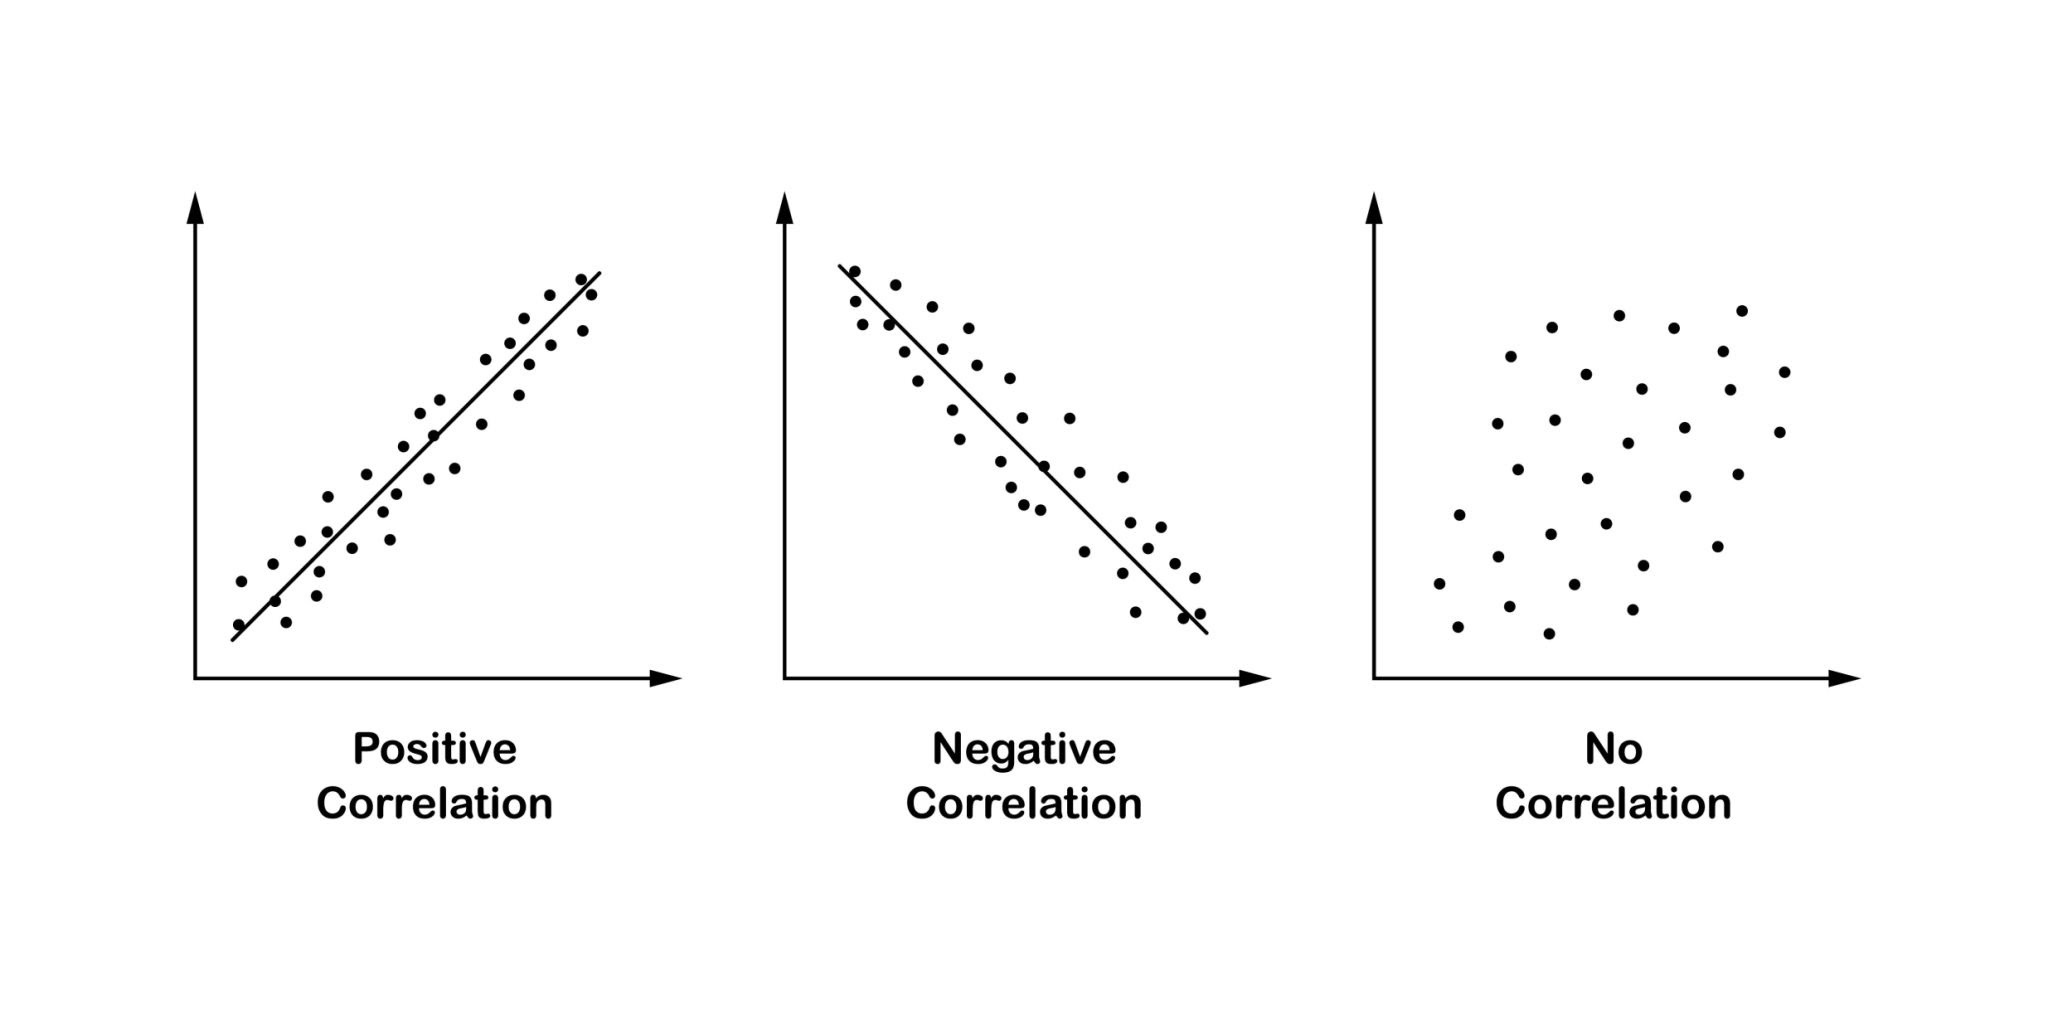

<center>Different directions of correlation. Source: Kharom Pleedee / Getty Images</center>

---

### The Mathematical Formula

The mathematical concept behind Pearson correlation is comparing how much the two variables vary *together* versus how much they vary *on their own*.

$$r = \frac{\text{Covariance of } X \text{ and } Y}{(\text{Standard Deviation of } X) \times (\text{Standard Deviation of } Y)}$$

By dividing the covariance (how they move together) by the product of their individual standard deviations (how they move independently), the formula beautifully normalizes the result, trapping it perfectly between $-1$ and $+1$ regardless of the original units.

---

### Two Massive Caveats

When data scientists use the Pearson correlation coefficient, they must always keep two strict limitations in mind to avoid embarrassing analytical mistakes:

**1. Correlation Does Not Imply Causation:**
Just because $r$ is close to $+1$ does not mean Variable X *causes* Variable Y. Ice cream sales and shark attacks have a very strong positive correlation. Eating ice cream doesn't cause shark attacks; they are both caused by a hidden third variable (summer weather).

**2. It Only Sees Straight Lines:**
Pearson correlation strictly measures *linear* relationships. If two variables have a perfect U-shaped or curved relationship (like caffeine intake vs. focus—a little helps, too much makes you jittery), the Pearson correlation coefficient might calculate as exactly $0.0$, falsely implying no relationship when a very strong (but non-linear) one exists.

---

This interactive tool allows you to physically drag data points around a scatterplot to see exactly how changing the shape of the data dynamically calculates the Pearson coefficient ($r$) in real-time.

Here is the complete Python code to build the interactive **Pearson Correlation Engine** directly in a Google Colab notebook.

While dragging individual points is easy in a web browser (like the D3.js widget above), Google Colab’s Python backend requires a slightly different approach for smooth interactivity.

Instead of dragging one point, this engine gives a **"Correlation Slider"**. As the slider is dragged from $+1.0$ down to $-1.0$, the engine mathematically transforms the sample data in real-time. The data points morph from a perfect upward line, dissolve into a random cloud of zero correlation, and then align into a perfect downward slope.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import ipywidgets as widgets
from IPython.display import display

# ==========================================
# 1. Generate the Base Sample Data
# ==========================================
# We set a random seed so the points move fluidly rather than jumping around
np.random.seed(42)
sample_size = 50

# Generate independent base variables
X_base = np.random.normal(0, 1, sample_size)
Z_base = np.random.normal(0, 1, sample_size)

# ==========================================
# 2. Define the Visualization Engine
# ==========================================
def plot_pearson(target_r):
    # Mathematically transform the Y values to achieve the exact target correlation
    # Formula: Y = (r * X) + (sqrt(1 - r^2) * Z)
    Y = (target_r * X_base) + (np.sqrt(1 - target_r**2) * Z_base)

    # Calculate the actual sample correlation coefficient
    r_actual, p_value = pearsonr(X_base, Y)

    # Calculate the Line of Best Fit (Linear Regression)
    m, b = np.polyfit(X_base, Y, 1)

    # Setup the plot
    plt.figure(figsize=(10, 6))

    # Plot the scatter points
    plt.scatter(X_base, Y, color='royalblue', s=80, alpha=0.8, edgecolors='black', zorder=3)

    # Plot the line of best fit
    x_line = np.linspace(-3.5, 3.5, 100)
    plt.plot(x_line, m*x_line + b, color='crimson', linewidth=3, linestyle='--',
             label='Line of Best Fit', zorder=2)

    # Formatting the visual graph
    plt.title(f'Pearson Correlation Coefficient (r) = {r_actual:.2f}', fontsize=16, pad=15)
    plt.xlabel('Variable X', fontsize=12)
    plt.ylabel('Variable Y', fontsize=12)

    # Lock the axes limits so the scale doesn't jump around while sliding
    plt.xlim(-3.5, 3.5)
    plt.ylim(-3.5, 3.5)

    # Draw faint axis lines at 0,0
    plt.axhline(0, color='gray', linewidth=1, alpha=0.5, zorder=1)
    plt.axvline(0, color='gray', linewidth=1, alpha=0.5, zorder=1)

    plt.grid(alpha=0.3, zorder=0)
    plt.legend(loc='upper left')

    # Add a dynamic text box interpreting the strength
    if r_actual >= 0.8: text = "Strong Positive"
    elif r_actual >= 0.4: text = "Moderate Positive"
    elif r_actual > -0.4: text = "Weak / No Correlation"
    elif r_actual > -0.8: text = "Moderate Negative"
    else: text = "Strong Negative"

    plt.text(1.8, -3.0, f"Relationship:\n{text}", fontsize=12, ha='center',
             bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.8'))

    plt.show()

# ==========================================
# 3. Create Interactive Controls
# ==========================================
# Create a slider to drag the correlation from -1 to +1
r_slider = widgets.FloatSlider(
    value=0.75,
    min=-1.0,
    max=1.0,
    step=0.05,
    description='Target Correlation (r):',
    continuous_update=True,
    layout=widgets.Layout(width='600px'),
    style={'description_width': 'initial'}
)

# Link the slider to the visualization function
interactive_pearson = widgets.interactive(plot_pearson, target_r=r_slider)

# Display the interactive UI
display(interactive_pearson)

interactive(children=(FloatSlider(value=0.75, description='Target Correlation (r):', layout=Layout(width='600p…

### What to look for when you run it:

* **The Line of Best Fit:** Notice how the red dashed line physically tilts based on the correlation. When $r$ is positive, it slopes up. When $r$ is negative, it slopes down.
* **The $0.0$ threshold:** When you drag the slider exactly to $0.0$, the line of best fit goes completely flat (horizontal). This visually proves that knowing the value of Variable X gives you absolutely zero ability to predict the value of Variable Y.
* **The clustering:** As $r$ gets closer to $+1.0$ or $-1.0$, the blue dots tightly hug the red line. As $r$ moves closer to $0$, the dots scatter wildly away from it.